In [1]:
import os
import pandas as pd
import plotnine as pln

In [59]:
#dir_path = '../experiments/fineTune/esmc_300m/DENV2_NS5_score_Suphatrakul2023/'
dir_path = '../experiments/fineTune/esmc_300m_v01/H1N1_NEP_enri_Teo2024'

def read_CSVLogger(dir_path):
    df = pd.read_csv(f"{dir_path}/metrics.csv")
    train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2"])
    val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2"])
    res = pd.merge(train_df, val_df, on=["epoch", "step"])
    res.rename(columns={"epoch": "Epoch"}, inplace=True)
    res['Epoch'] = res['Epoch'].astype(int) + 1
    # Filter rows where the difference between train_r2 and val_r2 is smaller than 0.1
    diff = res[abs(res['train_r2'] - res['val_r2']) < 0.1]
    best_epoch = diff['val_r2'].idxmax()
    res['best_epoch'] = best_epoch + 1
    return res

res = read_CSVLogger(dir_path)
res

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch
0,1,22,2.940414,-0.035822,1.071141,0.008185,3
1,2,45,3.105301,-0.032093,1.103357,-0.021646,3
2,3,68,3.000676,0.004996,1.070582,0.008702,3
3,4,91,3.038247,-0.011426,0.893278,0.172875,3
4,5,114,2.566512,0.138567,0.664489,0.384721,3
5,6,137,2.507588,0.167330,0.758657,0.297526,3
6,7,160,2.795161,0.064336,0.790535,0.268009,3
7,8,183,2.381255,0.187656,0.623409,0.422758,3
8,9,206,2.324277,0.226705,0.596050,0.448092,3
9,10,229,2.221872,0.263682,0.515180,0.522973,3


In [4]:
dts_order = [
    'BF520_env_Bloom2018',
    'BG505_env_Bloom2018',
    'PA_FLU_Sun2015',
    'HG_FLU_Bloom2016',

    'CVB3_capsid_MFE_Mattenberger2021',
    'CVB3_capsid_MFElog2_Mattenberger2021',

    'DENV2_NS5_score_Suphatrakul2023',

    'H1N1_NEP_enri_Teo2024',
    'H1N1_NEP_RF_Teo2024',

    'H3N2_HA_effect_Welsh2024',
    'H3N2_NA_fitness_Lei2023',

    'HIV1_Rev_SelCoeff_Fernandes2016',
    'HIV1_Tat_SelCoeff_Fernandes2016',
    
    'Zika_env_effect_Sourisseau2019',
    'Zika_env_log2effect_Sourisseau2019',

    'H1N1_PA_ddg_Wu2015',
    'H1N1_M1_RF_Wu2016',
    'H1N1_M1_maxRF_Wu2016',
    'H1N1_M2_RF_Wu2016',
    'H1N1_M2_maxRF_Wu2016',

    'OmiXBB15_spike_ACE2bind_Dadonaite2024',
    'OmiXBB15_spike_entry_Dadonaite2024',
    'OmiXBB15_spike_escape_Dadonaite2024',
    'Delta_spike_latent_Dadonaite2023',
    'Delta_spike_observed_Dadonaite2023',
 ]

In [60]:
res_dir = f'../experiments/fineTune/esmc_300m'

res = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    if 'Alvarez' not in dataset:
        dataset_dir = f'{res_dir}/{dataset}'
        df = read_CSVLogger(dataset_dir)
        df['Dataset'] = dataset
        df['Lab'] = dataset.split('_')[-1]
        res = pd.concat([res, df], ignore_index=True).reset_index(drop=True)

dts_order = list(res['Lab'].sort_values().unique())
res['Lab'] = pd.Categorical(res['Lab'], categories=dts_order, ordered=True)
res['Model'] = 'esmc_300m'
res

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch,Dataset,Lab,Model
0,1,528,4.263038,0.539275,2.584231,0.723268,18,AAV2_CAPSD_Sinai,Sinai,esmc_300m
1,2,1057,2.083945,0.774751,2.133909,0.771491,18,AAV2_CAPSD_Sinai,Sinai,esmc_300m
2,3,1586,1.702363,0.816017,1.481232,0.841383,18,AAV2_CAPSD_Sinai,Sinai,esmc_300m
3,4,2115,1.487444,0.839259,1.372880,0.852985,18,AAV2_CAPSD_Sinai,Sinai,esmc_300m
4,5,2644,1.415542,0.847027,1.442282,0.845553,18,AAV2_CAPSD_Sinai,Sinai,esmc_300m
...,...,...,...,...,...,...,...,...,...,...
327,18,773,1.025745,0.090156,0.879131,-0.029503,17,RmYN02_RBD_Starr,Starr,esmc_300m
328,19,816,1.005283,0.107199,0.925444,-0.083739,17,RmYN02_RBD_Starr,Starr,esmc_300m
329,20,859,0.997457,0.114703,0.809931,0.051533,17,RmYN02_RBD_Starr,Starr,esmc_300m
330,21,902,0.985250,0.125140,0.769493,0.098887,17,RmYN02_RBD_Starr,Starr,esmc_300m


In [26]:
# plot = (pln.ggplot(res)
#         + pln.geom_line(pln.aes(x='Epoch', y='train_loss', color="'Train Loss'"))
#         + pln.geom_line(pln.aes(x='Epoch', y='val_loss', color="'Validation Loss'"))
#         + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
#         + pln.xlab('Epoch')
#         + pln.ylab('Loss')
#         + pln.facet_wrap('Dataset', scales="free_y", ncol=3)
#         + pln.labs(color="Metric")
#         + pln.theme(figure_size=(9, 12)) 
#         )
# plot

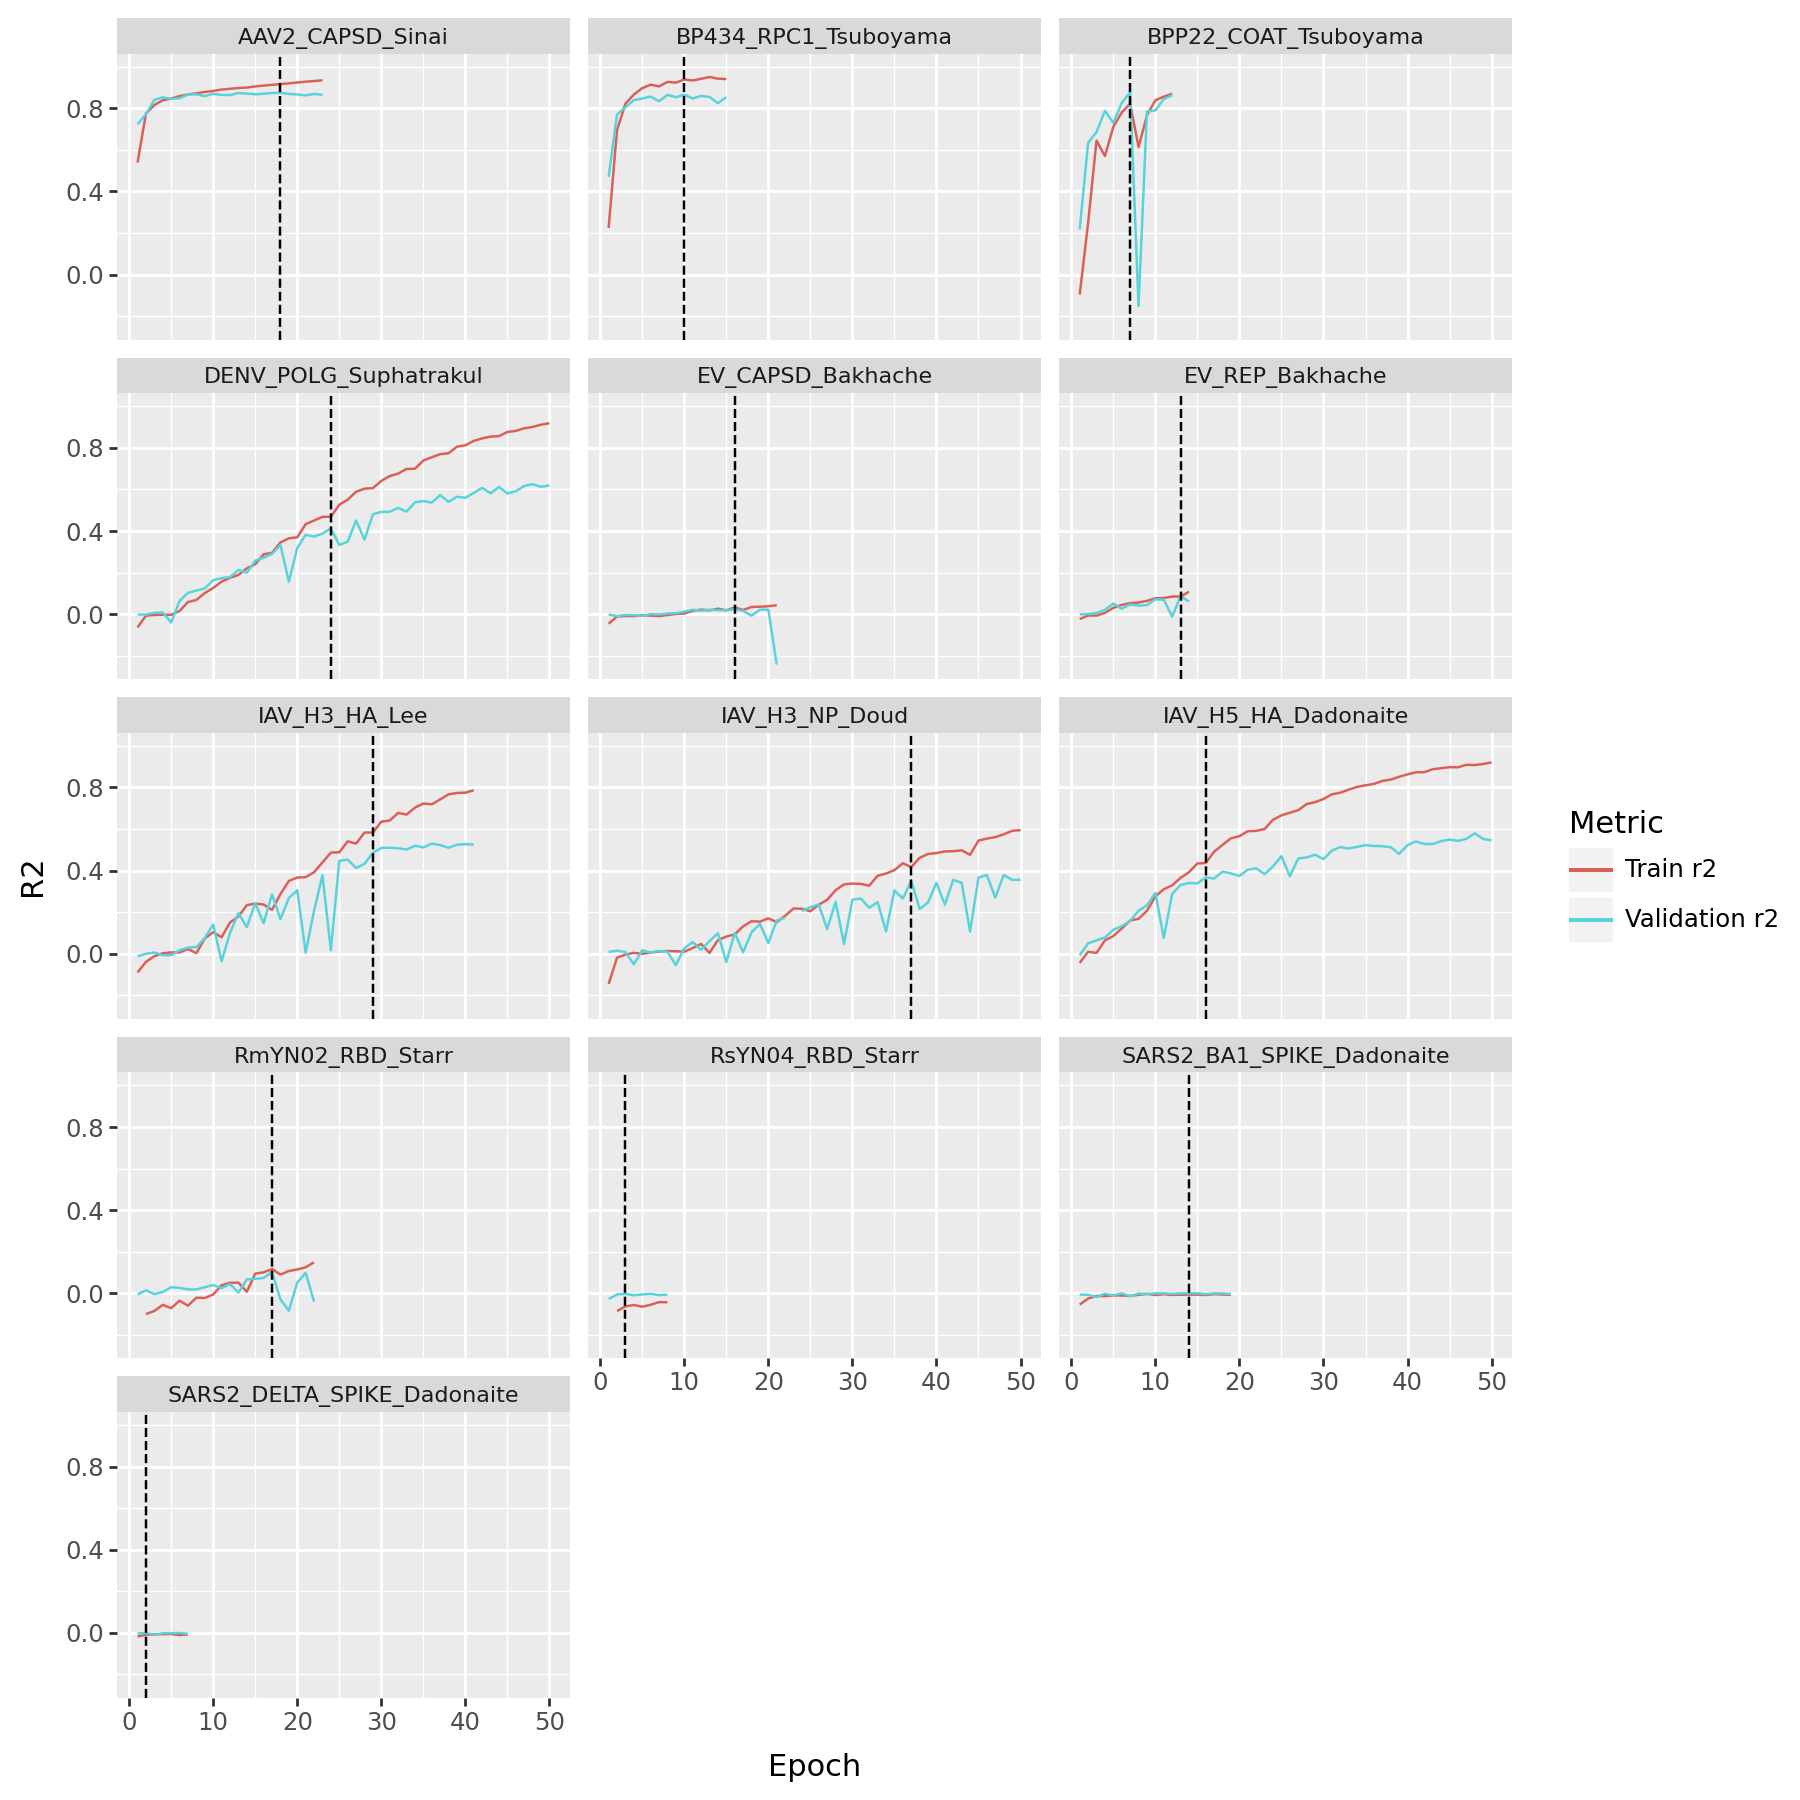

In [61]:
plot = (pln.ggplot(res)
        + pln.geom_line(pln.aes(x='Epoch', y='train_r2', color="'Train r2'"))
        + pln.geom_line(pln.aes(x='Epoch', y='val_r2', color="'Validation r2'"))
        + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
        + pln.xlab('Epoch')
        + pln.ylab('R2')        
        + pln.facet_wrap('Dataset',  ncol=3)
        + pln.labs(color="Metric")
        + pln.ylim(-0.25, 1)
        + pln.theme(figure_size=(9, 9), strip_text=pln.element_text(size=8)) 
        )
plot#.save(filename='../experiments/finetune_r2.png', dpi=600)

# vicam

In [62]:
res_dir = f'../experiments/fineTune/vicam_300m'
res2 = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    if 'Alvarez' not in dataset and "CVB3_POLG_Mattenberger" not in dataset:
       
        dataset_dir = f'{res_dir}/{dataset}'
        df = read_CSVLogger(dataset_dir)
        df['Dataset'] = dataset
        df['Lab'] = dataset.split('_')[-1]
        res2 = pd.concat([res2, df], ignore_index=True).reset_index(drop=True)


dts_order = list(res2['Lab'].sort_values().unique())

res2['Lab'] = pd.Categorical(res2['Lab'], categories=dts_order, ordered=True)
res2['Model'] = 'vicam_300m'
res2

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch,Dataset,Lab,Model
0,1,210,7.231861,-0.048203,6.835497,0.000085,12,DENV_POLG_Suphatrakul,Suphatrakul,vicam_300m
1,2,421,6.958765,-0.008667,6.960290,-0.018170,12,DENV_POLG_Suphatrakul,Suphatrakul,vicam_300m
2,3,632,6.954347,-0.008040,6.837613,-0.000225,12,DENV_POLG_Suphatrakul,Suphatrakul,vicam_300m
3,4,843,6.940871,-0.005777,6.837642,-0.000229,12,DENV_POLG_Suphatrakul,Suphatrakul,vicam_300m
4,5,1054,6.864980,0.005150,6.324827,0.074787,12,DENV_POLG_Suphatrakul,Suphatrakul,vicam_300m
...,...,...,...,...,...,...,...,...,...,...
753,7,153,0.202652,-0.031035,0.508172,-0.014249,6,IAV_PA_Wu,Wu,vicam_300m
754,8,175,0.204333,-0.058319,0.503975,-0.005871,6,IAV_PA_Wu,Wu,vicam_300m
755,9,197,0.213294,-0.076923,0.535224,-0.068240,6,IAV_PA_Wu,Wu,vicam_300m
756,10,219,0.201192,-0.018423,0.503699,-0.005322,6,IAV_PA_Wu,Wu,vicam_300m


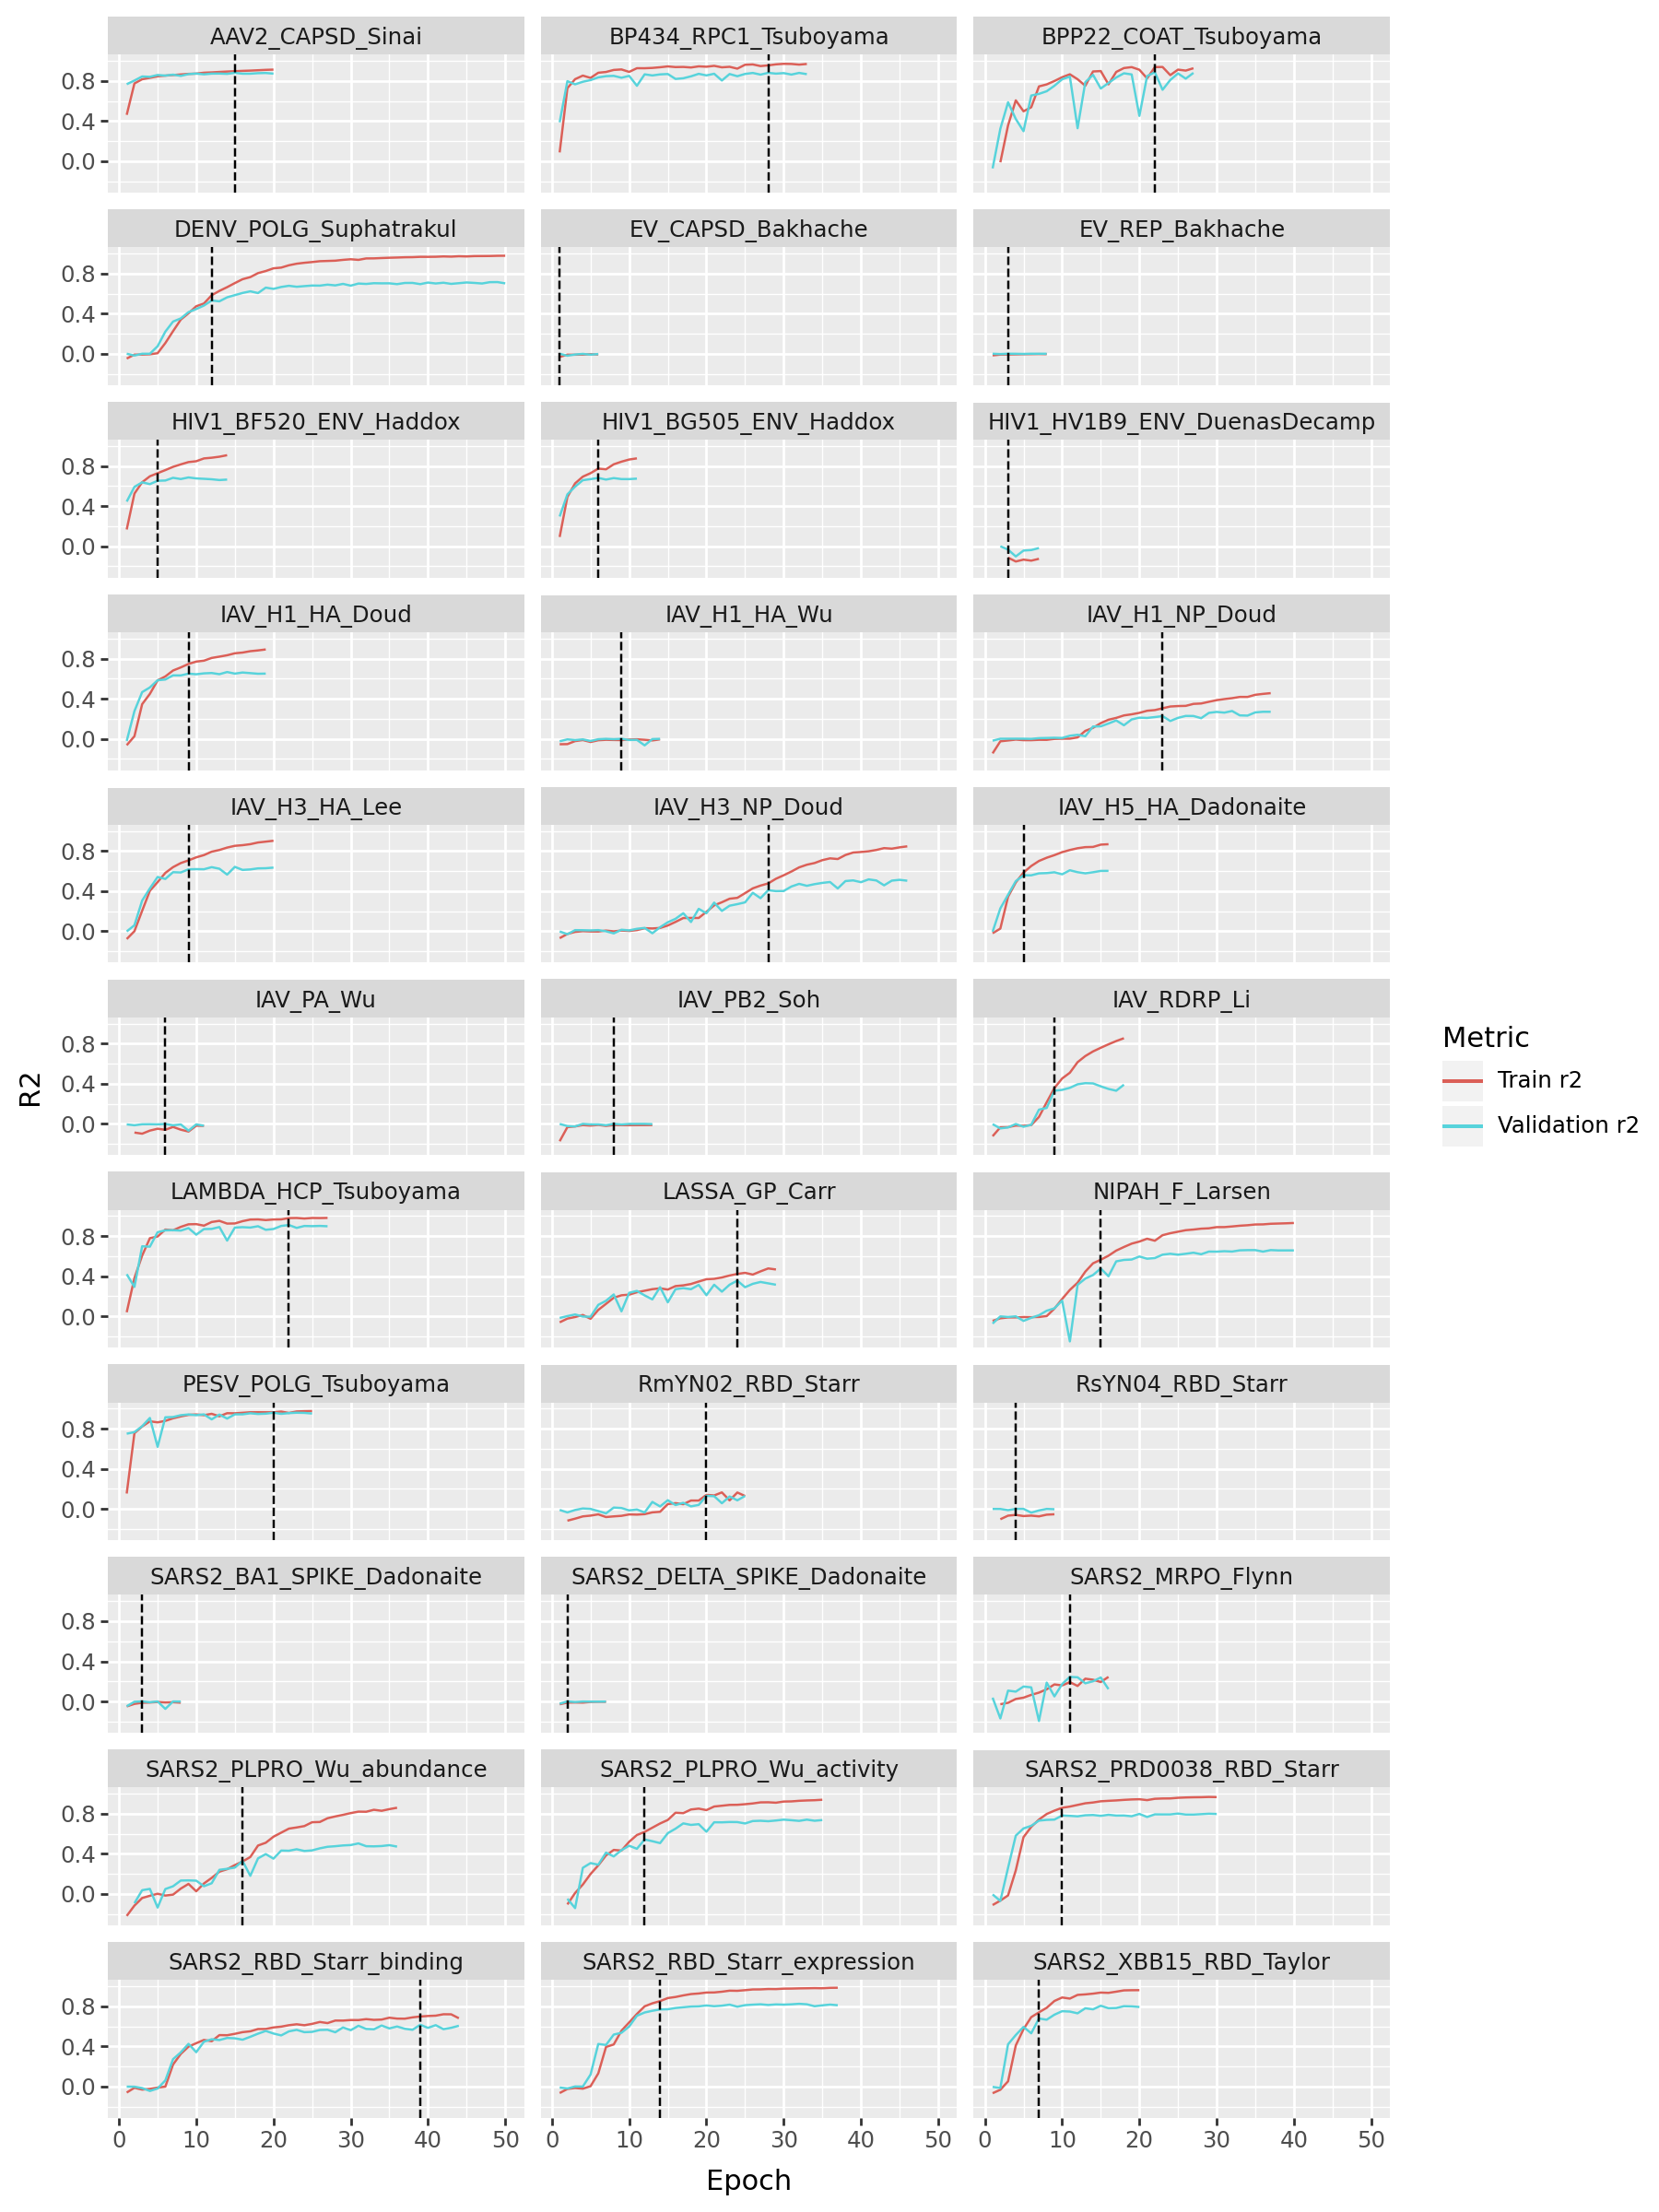

In [63]:
plot = (pln.ggplot(res2)
        + pln.geom_line(pln.aes(x='Epoch', y='train_r2', color="'Train r2'"))
        + pln.geom_line(pln.aes(x='Epoch', y='val_r2', color="'Validation r2'"))
        + pln.geom_vline(pln.aes(xintercept='best_epoch'), color='black', linetype='dashed')
        + pln.xlab('Epoch')
        + pln.ylab('R2')
        + pln.facet_wrap('Dataset',  ncol=3)
        + pln.labs(color="Metric")
        + pln.ylim(-0.25, 1)
        + pln.theme(figure_size=(9, 12)) 
        )
plot#.save(filename='../experiments/finetune_r2.png', dpi=600)

# Fitness finetune vicam x esmc

In [2]:
# Deleted: Dodonaite2024, wu2016

dts = [
    'BF520_env_Bloom2018', 'H3N2_HA_effect_Welsh2024',
    'BG505_env_Bloom2018', 'H3N2_NA_fitness_Lei2023', 
    'HG_FLU_Bloom2016', 'PA_FLU_Sun2015',
    'H1N1_NEP_enri_Teo2024', 'HIV1_Rev_SelCoeff_Fernandes2016', 'DENV2_NS5_score_Suphatrakul2023', 'H1N1_NEP_RF_Teo2024',
    'HIV1_Tat_SelCoeff_Fernandes2016', 'Zika_env_effect_Sourisseau2019',
    'Zika_env_log2effect_Sourisseau2019',
]


# dys = [
#     'BF520_env_Bloom2018', 'H1N1_M1_RF_Wu2016', 'H3N2_HA_effect_Welsh2024', 'OmiXBB15_spike_entry_Dadonaite2024',
#     'BG505_env_Bloom2018', 'H1N1_M2_maxRF_Wu2016', 'H3N2_NA_fitness_Lei2023', 'OmiXBB15_spike_escape_Dadonaite2024',
#     'CVB3_capsid_MFElog2_Mattenberger2021', 'H1N1_M2_RF_Wu2016', 'HG_FLU_Bloom2016', 'PA_FLU_Sun2015', 'CVB3_capsid_MFE_Mattenberger2021', 
#     'H1N1_NEP_enri_Teo2024', 'HIV1_Rev_SelCoeff_Fernandes2016', 'DENV2_NS5_score_Suphatrakul2023', 'H1N1_NEP_RF_Teo2024',
#     'HIV1_Tat_SelCoeff_Fernandes2016', 'Zika_env_effect_Sourisseau2019',
#     'H1N1_PA_ddg_Wu2015', 'H1N1_M1_maxRF_Wu2016', 'OmiXBB15_spike_ACE2bind_Dadonaite2024', 'Zika_env_log2effect_Sourisseau2019',
#     'Delta_spike_observed_Dadonaite2023', 'Delta_spike_latent_Dadonaite2023',
# ]

In [3]:
def read_CSVLogger(dir_path):
    df = pd.read_csv(f"{dir_path}/metrics.csv")
    train_df = df[df["train_loss"].notna()].copy().drop(columns=["val_loss", "val_r2"])
    val_df = df[df["val_loss"].notna()].copy().drop(columns=["train_loss", "train_r2"])
    res = pd.merge(train_df, val_df, on=["epoch", "step"])
    res.rename(columns={"epoch": "Epoch"}, inplace=True)
    res['Epoch'] = res['Epoch'].astype(int) + 1
    # Filter rows where the difference between train_r2 and val_r2 is smaller than 0.1
    diff = res[abs(res['train_r2'] - res['val_r2']) < 0.1]
    best_epoch = diff['val_r2'].idxmax()
    res['best_epoch'] = best_epoch + 1
    res = res.iloc[[best_epoch], :]
    return res

In [4]:

res_dir = f'../experiments/fineTune/esmc_300m_v01'
res = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    dataset_dir = f'{res_dir}/{dataset}'
    df = read_CSVLogger(dataset_dir)
    df['Dataset'] = dataset
    res = pd.concat([res, df], ignore_index=True).reset_index(drop=True)
res['Model'] = 'esmc_300m'


res_dir = f'../experiments/fineTune/vicam_300m_v01'
res2 = pd.DataFrame()
for dataset in os.listdir(f'{res_dir}/'):
    dataset_dir = f'{res_dir}/{dataset}'
    df = read_CSVLogger(dataset_dir)
    df['Dataset'] = dataset
    res2 = pd.concat([res2, df], ignore_index=True).reset_index(drop=True)
res2['Model'] = 'vicam_300m'


res_full = pd.concat([res, res2], ignore_index=True)
res_full = res_full.query('Dataset in @dts')
res_full

,Epoch,step,train_loss,train_r2,val_loss,val_r2,best_epoch,Dataset,Model
1,28,2211,0.136057,0.283614,0.134525,0.281022,28,H3N2_NA_fitness_Lei2023,esmc_300m
4,19,2393,0.222741,0.073298,0.152955,0.133159,19,Zika_env_effect_Sourisseau2019,esmc_300m
6,4,635,1.188627,0.760385,1.518488,0.691602,4,BG505_env_Bloom2018,esmc_300m
13,4,627,1.202224,0.732400,1.469455,0.658551,4,BF520_env_Bloom2018,esmc_300m
14,17,3586,3.105039,0.547615,3.764080,0.459990,17,DENV2_NS5_score_Suphatrakul2023,esmc_300m
15,19,436,0.085079,0.599891,0.073287,0.544538,19,H1N1_NEP_RF_Teo2024,esmc_300m
17,12,1511,3.774828,0.136148,3.436333,0.188988,12,Zika_env_log2effect_Sourisseau2019,esmc_300m
18,23,1356,1.051389,0.183393,1.078231,0.111991,23,H3N2_HA_effect_Welsh2024,esmc_300m
19,13,415,0.273599,-0.034672,0.257998,-0.000086,13,PA_FLU_Sun2015,esmc_300m
20,24,3359,0.732733,0.561714,0.933124,0.469544,24,HG_FLU_Bloom2016,esmc_300m


In [6]:
res_full['Model'] = pd.Categorical(res_full['Model'], categories=['vicam_300m', 'esmc_300m'], ordered=True)

In [8]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='val_r2'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Source',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 6),
        panel_grid_major_x=pln.element_blank(),
    )
    + pln.ylim(-0.2, .8)
    #+ pln.facet_wrap('split_method', ncol=2, scales='free_y')
)

plot.save(filename='../experiments/finetune_r2_vicam300m_x_esmc300m.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 6 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/finetune_r2_vicam300m_x_esmc300m.png
